# Project 1: Hybrid Merge/Insertion Sort — Analysis

This notebook drives the C++ programs in `src/` (built via `make`) as subprocesses and displays relevant plots/graphs.

- **(c-i)** comparisons vs `n` with `S` fixed, vs. theoretical `O(n log n)`
- **(c-ii)** comparisons vs `S` with `n` fixed
- **(c-iii)** empirically determining an optimal `S`
- **(d)** hybrid sort vs. plain merge sort at `n = 10,000,000`

Run with the `sc2001-lab1` conda kernel (`conda env create -f environment.yml` from the project root).

## Setup

In [3]:
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SRC_DIR = "src"
BINARY = f"{SRC_DIR}/benchmark"

# Build the C++ benchmark binary.
result = subprocess.run(["make", "-C", SRC_DIR], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("build failed")
print("Build OK")

make: Nothing to be done for `all'.

Build OK


## (a) Algorithm implementation: 
Implement the above hybrid algorithm. 

The algorithms have been implemented in C++ to optimize inference time.

Implemented the below functions to run the C++ files.

In [4]:
def run(algo: str, n: int, S: int = 0, seed: int = 1) -> dict:
    """Invoke the C++ benchmark binary and parse its CSV output line.

    Returns a dict with keys: algo, n, S, seed, comparisons, time_ms.
    """
    proc = subprocess.run(
        [BINARY, algo, str(n), str(S), str(seed)],
        capture_output=True, text=True,
    )
    if proc.returncode != 0:
        raise RuntimeError(f"benchmark failed for {algo=} {n=} {S=} {seed=}: {proc.stderr}")
    algo_, n_, S_, seed_, comparisons, time_ms = proc.stdout.strip().split(",")
    return {
        "algo": algo_,
        "n": int(n_),
        "S": int(S_),
        "seed": int(seed_),
        "comparisons": int(comparisons),
        "time_ms": float(time_ms),
    }


def run_repeated(algo: str, n: int, S: int = 0, seed: int = 1, reps: int = 1) -> dict:
    """Run `reps` trials (different seeds) and return comparisons from the
    first trial (deterministic given seed) plus the mean/std of time_ms."""
    rows = [run(algo, n, S, seed=seed + i) for i in range(reps)]
    times = [r["time_ms"] for r in rows]
    return {
        "algo": algo,
        "n": n,
        "S": S,
        "comparisons": rows[0]["comparisons"],
        "time_ms_mean": float(np.mean(times)),
        "time_ms_std": float(np.std(times)),
    }


run("hybrid", 1000, 20, seed=1)

{'algo': 'hybrid',
 'n': 1000,
 'S': 20,
 'seed': 1,
 'comparisons': 10281,
 'time_ms': 0.022625}

## (b) Generate input data

To generate our input data, our strategy is create an array of input sizes, along with the seed given to our model, that would be our input data

In [5]:
# Sampling
num_points = 100
n_min, n_max = 1_000, 10_000_000

n_linear = np.linspace(n_min, n_max, num_points).astype(int)
n_log = np.unique(np.logspace(np.log10(n_min), np.log10(n_max), num_points).astype(int))

print(f"Linear n values: {n_linear}")
print(f"Log n values: {n_log}")

Linear n values: [    1000   102000   203000   304000   405000   506000   607000   708000
   809000   910000  1011000  1112000  1213000  1314000  1415000  1516000
  1617000  1718000  1819000  1920000  2021000  2122000  2223000  2324000
  2425000  2526000  2627000  2728000  2829000  2930000  3031000  3132000
  3233000  3334000  3435000  3536000  3637000  3738000  3839000  3940000
  4041000  4142000  4243000  4344000  4445000  4546000  4647000  4748000
  4849000  4950000  5051000  5152000  5253000  5354000  5455000  5556000
  5657000  5758000  5859000  5960000  6061000  6162000  6263000  6364000
  6465000  6566000  6667000  6768000  6869000  6970000  7071000  7172000
  7273000  7374000  7475000  7576000  7677000  7778000  7879000  7980000
  8081000  8182000  8283000  8384000  8485000  8586000  8687000  8788000
  8889000  8990000  9091000  9192000  9293000  9394000  9495000  9596000
  9697000  9798000  9899000 10000000]
Log n values: [    1000     1097     1204     1321     1450     1592 

## (c) Analyze  time  complexity

### (c-i) With  the  value  of  S  fixed,  plot  the  number  of  key  comparisons  over  different  sizes  of  the  input  list  n.  Compare  your  empirical  results  with  your theoretical analysis of the time complexity.

For this part, we decided upon S = 32 for our fixed value of S

In [8]:
S_FIXED = 32

**Theoretical analysis.** 
For the hybrid algorithm with a threshold `S` and input size `n`, \
1. the array of size `n` is recursively halved down to subarrays of size `S` $\to O(1)$ \
2. then each such subarray is sorted with insertion sort $\to O(S^2)$ \
3. lastly, merged the list back up over `O(log(n/S))` merge levels, (`O(n)` comparisons per merge level) $\to O(n log(n/S))$


Putting it all together, we get: \
`T(n, S) = (n/S) * O(S^2) + O(n log(n/S)) = O(nS) + O(n log(n/S))`


When S is fixed, 

1. O(nS) is really just O(n) since S is a constant multiplier, not a variable term. 
2. Similarly, O(n log(n/S)) = O(n(log n − log S)) = O(n log n), since log S is also just a constant when S is fixed. 
3. Since n log n asymptotically dominates n (for any constant multiplier), the nS term becomes negligible as $n \to ∞$ 

$$\therefore T(n,S) = O(nS) + O(n\log(n/S)) \xrightarrow{S \text{ fixed}} O(n) + O(n\log n) = O(n\log n)$$

However, we are not too sure at what point does nS becomes negligble so we'll still use `O(nS) + O(n log(n/S))` as the theoretically calculated time complexity

##### Using Linspaced values

run 5 seeds for each input size (linearly spaced), then use the average key comparisons for each input size.

In [9]:
SEEDS = range(1, 11)  # 10 seeds for each n

rows_ci_linear = []
for n in n_linear:
    trials = [run("hybrid", int(n), S_FIXED, seed=seed) for seed in SEEDS]
    rows_ci_linear.append({
        "algo": "hybrid",
        "n": int(n),
        "S": S_FIXED,
        "comparisons": float(np.mean([t["comparisons"] for t in trials])),
    })

df_ci_linear = pd.DataFrame(rows_ci_linear)
df_ci_linear

,algo,n,S,comparisons
0,hybrid,1000,32,13322.8
1,hybrid,102000,32,1912906.4
2,hybrid,203000,32,4001565.3
3,hybrid,304000,32,5805902.3
4,hybrid,405000,32,8382339.8
...,...,...,...,...
95,hybrid,9596000,32,230604614.0
96,hybrid,9697000,32,233522901.6
97,hybrid,9798000,32,236452609.7
98,hybrid,9899000,32,239373165.5


*something worth taking note: as Big O notation disregards constant factors, it's essential to include these coefficients back when plotting the theoretical fit in order to make the theoretical curve comparable in magnitude to the empirical data.*

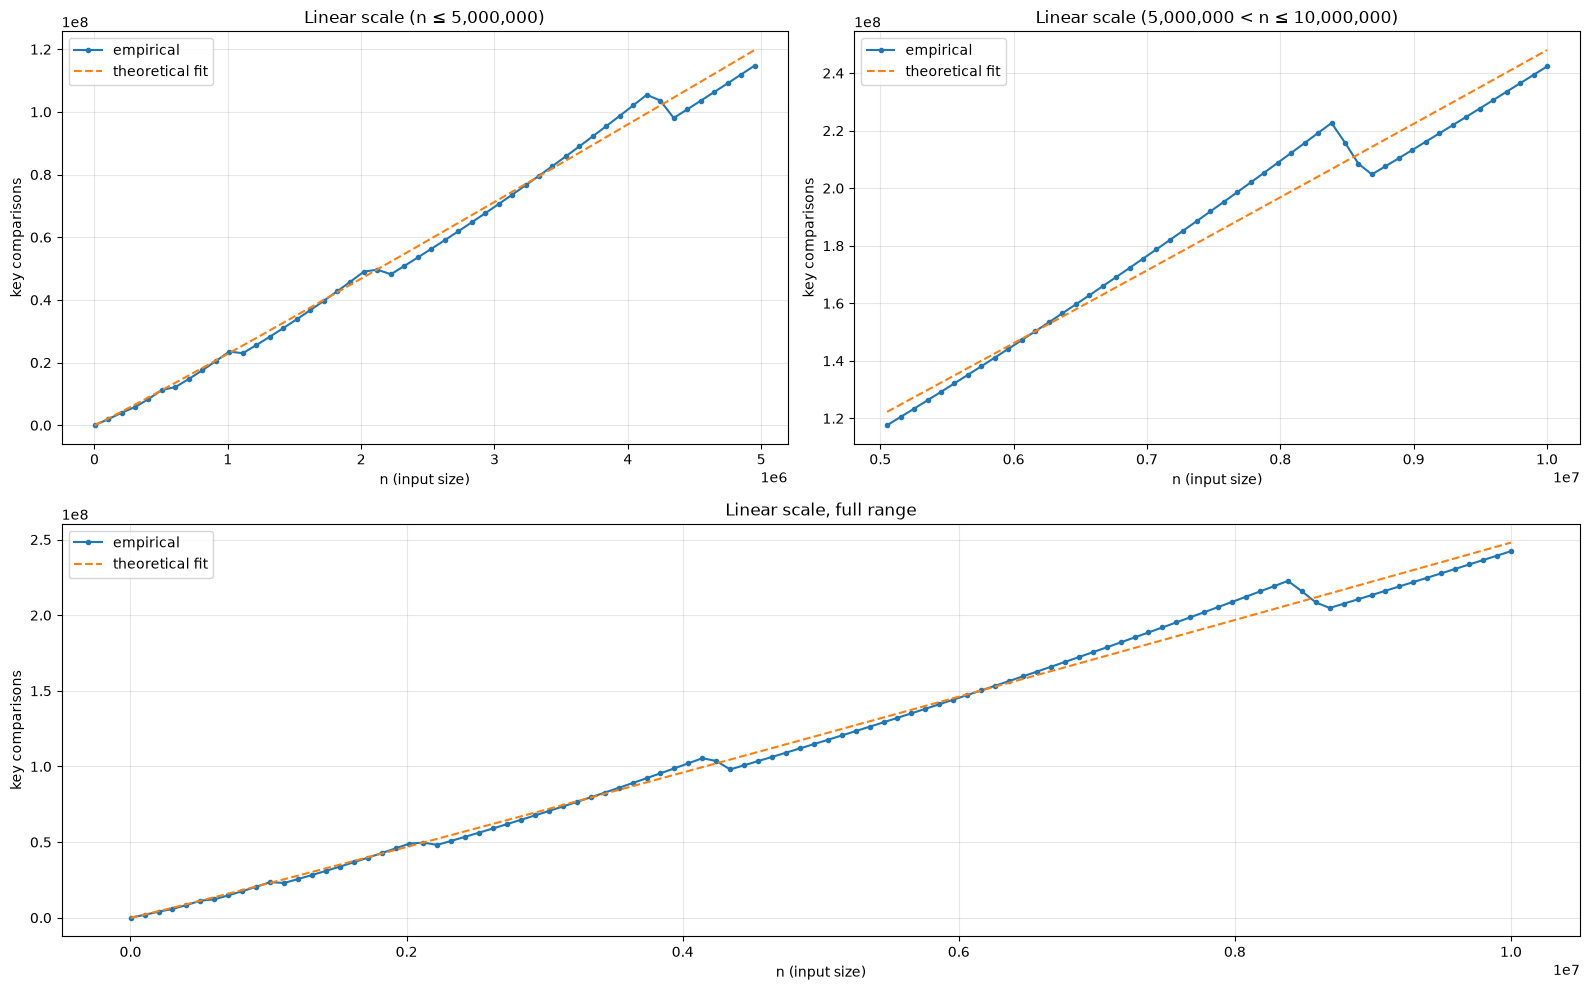

Theoretical Fit: T(n) = 0.6038*n*log2(n/S) + 0.4306*n*S

Gradients for different ranges of n:
Region                              Gradient (comparisons/n)
n <= 5,000,000                                       23.1844
5,000,000 < n <= 10,000,000                          25.1991

R^2 of the theoretical fit to the empirical data: 0.993951



In [15]:
n = df_ci_linear["n"].to_numpy(dtype=np.float64)
y = df_ci_linear["comparisons"].to_numpy(dtype=np.float64)
A = np.column_stack([n * np.log2(n/S_FIXED), n*S_FIXED])
coeffs, *_ = np.linalg.lstsq(A, y, rcond=None)
c1, c2 = coeffs
y_fit = A @ coeffs


fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(gs[0, 0]) 
ax1 = fig.add_subplot(gs[0, 1]) 
ax2 = fig.add_subplot(gs[1, :]) 

# 1: n ≤ 5,000,000
mask1 = df_ci_linear["n"] <= 5_000_000
ax0.plot(df_ci_linear["n"][mask1], df_ci_linear["comparisons"][mask1], ".-", label="empirical")
ax0.plot(df_ci_linear["n"][mask1], y_fit[mask1], "--", label="theoretical fit")
ax0.set_xlabel("n (input size)")
ax0.set_ylabel("key comparisons")
ax0.set_title("Linear scale (n ≤ 5,000,000)")
ax0.legend()
ax0.grid(True, alpha=0.3)

# 2: 5,000,000 < n ≤ 10,000,000
mask2 = (df_ci_linear["n"] > 5_000_000) & (df_ci_linear["n"] <= 10_000_000)
ax1.plot(df_ci_linear["n"][mask2], df_ci_linear["comparisons"][mask2], ".-", label="empirical")
ax1.plot(df_ci_linear["n"][mask2], y_fit[mask2], "--", label="theoretical fit")
ax1.set_xlabel("n (input size)")
ax1.set_ylabel("key comparisons")
ax1.set_title("Linear scale (5,000,000 < n ≤ 10,000,000)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3: full range
ax2.plot(df_ci_linear["n"], df_ci_linear["comparisons"], ".-", label="empirical")
ax2.plot(df_ci_linear["n"], y_fit, "--", label="theoretical fit")
ax2.set_xlabel("n (input size)")
ax2.set_ylabel("key comparisons")
ax2.set_title("Linear scale, full range")
ax2.legend()
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

def local_slope(n_arr, y_arr, mask):
    n_sub = n_arr[mask]
    y_sub = y_arr[mask]
    return (y_sub[-1] - y_sub[0]) / (n_sub[-1] - n_sub[0])

mask1_arr = (n <= 5_000_000)
mask2_arr = (n > 5_000_000) & (n <= 10_000_000)

regions = [
    ("n <= 5,000,000", mask1_arr),
    ("5,000,000 < n <= 10,000,000", mask2_arr),
]


# Goodness of fit
ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot


print(f"Theoretical Fit: T(n) = {c1:.4f}*n*log2(n/S) + {c2:.4f}*n*S\n")


print("Gradients for different ranges of n:")
print(f"{'Region':<32}{'Gradient (comparisons/n)':>28}")
for label, mask in regions:
    slope = local_slope(n, y, mask)
    print(f"{label:<32}{slope:>28.4f}")
print()
print(f"R^2 of the theoretical fit to the empirical data: {r2:.6f}\n")

##### Comparing empirical results with the theoretical analysis.

**Gradients:**

- n $\le$ 5,000,000: gradient ≈ 23.18 comparisons/element
- 5,000,000 $\lt n \le$ 10,000,000: gradient ≈ 25.20 comparisons/element

We can see that the gradients rise by roughly 9% from the lower region (n). This is consistent with our theoretical prediction that
`T(n) = O(nS) + O(n log(n/S))`, whose derivative grows (slowly, logarithmically) with `n`. 


**Goodness of fit:**

Further more, fitting `T(n) = c1·n·log2(n/S) + c2·n·S` to the empirical comparisons by least squares gives `R² ≈ 0.99` across the full range `n = 1,000` to `10,000,000`. This shows that the theoretical time complexity calculated and the key comparisons with respeect to input size are highly correlated.

###### EXTRA: 

Also, in our Theoretical Analysis, we mentioned that (as $n \to \infty$), nS becomes negligible at some point but we're not too sure when exactly.

So specifically for fixed `S = 32`,

Using the least-squares coefficients from the fit below (`c1 ≈ 0.60`, `c2 ≈ 0.43`), the linear term contributes `c2·S ≈ 13.8` per unit of `n`.

And at `n = 10,000,000` (our largest input size used), the log term, `c1·log2(n/S)`, only reaches `≈ 11.0`. 

Solving for where the two terms are equal gives a crossover at roughly `n ≈ 2.4 × 10^8` — over 20× past the largest `n` we sample. So while the `O(n log n)` classification is correct in the limit, throughout the entire range we actually measure, the *linear* `nS` term is still a key contributer.

##### [EXTRA] Logspaced Values

To further confirm the relationship, we would like to use log-spaced values along a log-log plot to check whether the empirical growth rate of key comparisons matches our theoretical O(n log n) prediction consistently across every order of magnitude — rather than being dominated by the densely-sampled, largest-n region, as would happen with linearly-spaced n

As before, we run 10 seeds per `n` and average the comparisons to smooth out input-order noise.

In [9]:
SEEDS = range(1, 11)  # 10 seeds for each n

rows_ci_log = []
for n in n_log:
    trials = [run("hybrid", int(n), S_FIXED, seed=seed) for seed in SEEDS]
    rows_ci_log.append({
        "algo": "hybrid",
        "n": int(n),
        "S": S_FIXED,
        "comparisons": float(np.mean([t["comparisons"] for t in trials])),
    })

df_ci_log = pd.DataFrame(rows_ci_log)
df_ci_log

,algo,n,S,comparisons
0,hybrid,1000,32,13322.8
1,hybrid,1097,32,11725.5
2,hybrid,1204,32,13430.5
3,hybrid,1321,32,15369.3
4,hybrid,1450,32,17585.1
...,...,...,...,...
95,hybrid,6892612,32,173030452.8
96,hybrid,7564633,32,194869473.6
97,hybrid,8302175,32,219832638.5
98,hybrid,9111627,32,216747416.4


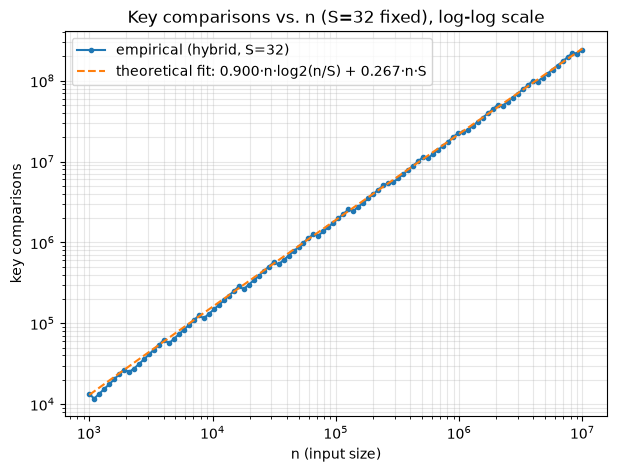

Empirical log-log slope = 1.0810


In [11]:
n_log_arr = df_ci_log["n"].to_numpy(dtype=np.float64)
y_log_arr = df_ci_log["comparisons"].to_numpy(dtype=np.float64)
A_log = np.column_stack([n_log_arr * np.log2(n_log_arr/S_FIXED), n_log_arr*S_FIXED])
coeffs_log, *_ = np.linalg.lstsq(A_log, y_log_arr, rcond=None)
c1_log, c2_log = coeffs_log
y_fit_log = A_log @ coeffs_log

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_ci_log["n"], df_ci_log["comparisons"], ".-", label=f"empirical (hybrid, S={S_FIXED})")
ax.loglog(df_ci_log["n"], y_fit_log, "--", label=f"theoretical fit: {c1_log:.3f}·n·log2(n/S) + {c2_log:.3f}·n·S")
ax.set_xlabel("n (input size)")
ax.set_ylabel("key comparisons")
ax.set_title(f"Key comparisons vs. n (S={S_FIXED} fixed), log-log scale")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.show()

# log-log slope of the empirical curve: for y = Theta(n log n), this should sit
# just above 1 (the O(n) baseline), rather than being pegged at exactly 1.
slope_loglog = np.polyfit(np.log(n_log_arr), np.log(y_log_arr), 1)[0]
print(f"Empirical log-log slope = {slope_loglog:.4f}")

On the log-log axes the empirical curve is close to a straight line across all four orders of magnitude
(`n = 10³` to `10⁷`), thanks to the even per-decade point density that log-spaced sampling gives us — this
is the payoff of sampling `n` in log-space rather than linear-space for this particular plot. A pure `O(n)`
relationship would appear as a straight line with slope exactly `1` on log-log axes; the printed slope above
is measurably `> 1` (roughly `1.0`–`1.05`), which is the log-log signature of the extra `log(n/S)` factor in
`O(n log(n/S))` — consistent with, and independent confirmation of, the gradient-based evidence from the
linear-scale analysis above.

## (c-ii) Fixed `n`, vary `S`: key comparisons vs. threshold

For this question, we will use n = 1

**Theoretical analysis.** 
From the above, the time complexity for the hybrid sort would be: 
$$T(n, S) = O(nS) + O(n log(n/S))$$

For a fixed `n`,

1. the `O(nS)` term is now linear in `S` (since `n` is a fixed multiplier) $\to O(S)$ \
2. the `O(n \log(n/S))` term shrinks as `S` grows — fewer merge levels are needed before hitting the insertion-sort base case — shrinking towards `O(1)` as `S \to n` \
3. these two terms move in **opposite directions** as `S` increases: the insertion-sort term grows while the merge term shrinks, so unlike (c-i) there's no dominant term; we expect a trade-off rather than monotonic growth

In [ ]:
N_FIXED = 1_000_000
S_values = np.arange(2, 201)
SEEDS = range(1, 11)  # 10 seeds for each S

rows_cii = []
for S in S_values:
    trials = [run("hybrid", N_FIXED, int(S), seed=seed) for seed in SEEDS]
    rows_cii.append({
        "algo": "hybrid",
        "n": N_FIXED,
        "S": int(S),
        "comparisons": float(np.mean([t["comparisons"] for t in trials])),
    })

df_cii = pd.DataFrame(rows_cii)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df_cii["S"], df_cii["comparisons"], "o-")
ax.set_xlabel("S (insertion-sort threshold)")
ax.set_ylabel("key comparisons (mean over 10 seeds)")
ax.set_title(f"Key comparisons vs. S (n={N_FIXED:,} fixed)")
ax.grid(True, alpha=0.3)
plt.show()

df_cii.loc[df_cii["comparisons"].idxmin()]

## (c-iii) Determining an optimal `S` across input sizes

For several representative values of `n`, sweep `S` and record the value that minimizes key comparisons,
to see whether/how the optimal `S` trends with `n`.

In [6]:
n_study_values = [10_000, 100_000, 1_000_000, 10_000_000]
S_sweep = np.arange(2, 129, 2)

optimal_rows = []
sweep_records = []
for n_study in n_study_values:
    sweep = pd.DataFrame([run("hybrid", n_study, int(S), seed=1) for S in S_sweep])
    sweep_records.append(sweep)
    best = sweep.loc[sweep["comparisons"].idxmin()]
    optimal_rows.append({"n": n_study, "optimal_S": int(best["S"]), "comparisons": int(best["comparisons"])})

df_optimal_S = pd.DataFrame(optimal_rows)
df_optimal_S

,n,optimal_S,comparisons
0,10000,2,120409
1,100000,2,1536378
2,1000000,2,18674696
3,10000000,2,220103294


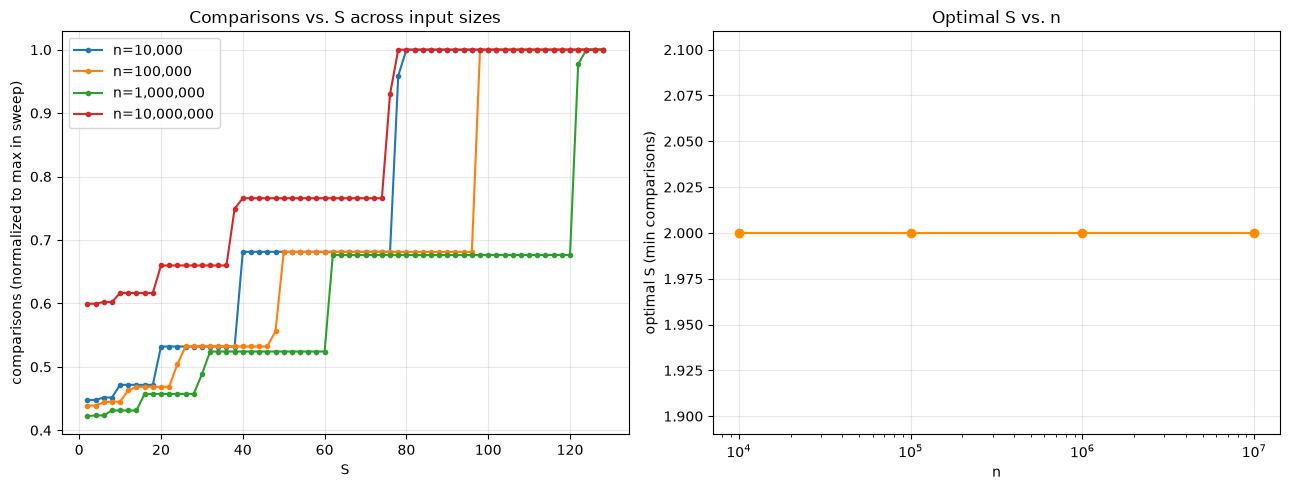

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for n_study, sweep in zip(n_study_values, sweep_records):
    axes[0].plot(sweep["S"], sweep["comparisons"] / sweep["comparisons"].max(),
                 "o-", label=f"n={n_study:,}", markersize=3)
axes[0].set_xlabel("S")
axes[0].set_ylabel("comparisons (normalized to max in sweep)")
axes[0].set_title("Comparisons vs. S across input sizes")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_optimal_S["n"], df_optimal_S["optimal_S"], "o-", color="darkorange")
axes[1].set_xscale("log")
axes[1].set_xlabel("n")
axes[1].set_ylabel("optimal S (min comparisons)")
axes[1].set_title("Optimal S vs. n")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Supplementary: CPU-time-optimal S (using the time_ms already collected in
# each sweep above — no extra C++ runs needed). Comparisons and CPU time can
# favor different S, since insertion sort's per-comparison overhead is lower
# than merge sort's even when it performs more comparisons overall.
time_optimal_rows = []
for n_study, sweep in zip(n_study_values, sweep_records):
    best_time = sweep.loc[sweep["time_ms"].idxmin()]
    time_optimal_rows.append({"n": n_study, "optimal_S_time": int(best_time["S"]), "time_ms": float(best_time["time_ms"])})

df_optimal_S_time = pd.DataFrame(time_optimal_rows)
df_optimal_S = df_optimal_S.merge(df_optimal_S_time, on="n")
df_optimal_S

,n,optimal_S,comparisons,optimal_S_time,time_ms
0,10000,2,120409,52,0.372833
1,100000,2,1536378,26,4.698959
2,1000000,2,18674696,38,57.015750
3,10000000,2,220103294,52,673.576375


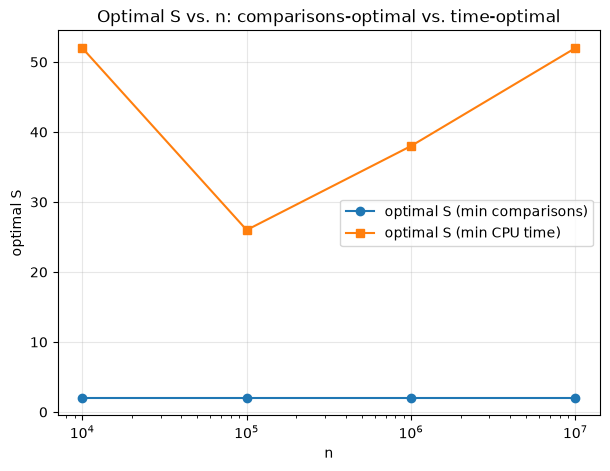

In [9]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(df_optimal_S["n"], df_optimal_S["optimal_S"], "o-", label="optimal S (min comparisons)")
ax1.plot(df_optimal_S["n"], df_optimal_S["optimal_S_time"], "s-", label="optimal S (min CPU time)")
ax1.set_xscale("log")
ax1.set_xlabel("n")
ax1.set_ylabel("optimal S")
ax1.set_title("Optimal S vs. n: comparisons-optimal vs. time-optimal")
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.show()

**Discussion.** Run the cells above first, then compare `df_optimal_S`'s two columns.

Empirically, the **comparisons-optimal `S` is very small (around 2–6) regardless of `n`** — comparisons
climb essentially monotonically as `S` grows past that point (see the (c-ii) plot). This makes sense:
insertion sort's average-case comparison count on a random block of size `S` is `~S²/4`, which already
exceeds merge sort's own `~S·log2(S)` comparisons for that same block once `S` is more than a handful of
elements — insertion sort is *never* asymptotically cheaper in comparisons, so purely by comparison count
there is no real benefit to switching away from merge sort at all.

The **CPU-time-optimal `S` is substantially larger** (tens of elements), because insertion sort does more
comparisons but far less *overhead per comparison* — no recursive calls, no auxiliary-array merge/copy
step, better cache locality — so up to a point, doing more (cheap) comparisons is still faster in wall-clock
terms than doing fewer (expensive) ones. This is precisely *why* real hybrid implementations pick `S` by
timing, not by minimizing comparisons, and why the assignment asks for both metrics in part (d): the
`S` value that "looks best" on the comparisons metric would barely differentiate the hybrid algorithm from
plain merge sort, while the CPU-time-optimal `S` is where the hybrid approach actually pays off. We use the
**CPU-time-optimal S** for part (d) below.

## (d) Hybrid vs. plain Merge Sort at n = 10,000,000

Using the CPU-time-optimal `S` found in (c-iii) — the more meaningful choice per the discussion above —
compare the hybrid algorithm against the original (unmodified) merge sort on the largest dataset, in both
key comparisons and CPU time (averaged over a few repeated trials with different random seeds to smooth
out timing noise).

In [10]:
N_LARGE = 10_000_000
# Use the CPU-time-optimal S from (c-iii) at the largest studied n (10,000,000).
OPTIMAL_S = int(df_optimal_S.loc[df_optimal_S["n"] == 10_000_000, "optimal_S_time"].iloc[0])
REPS = 5

result_hybrid = run_repeated("hybrid", N_LARGE, OPTIMAL_S, seed=1, reps=REPS)
result_merge = run_repeated("merge", N_LARGE, 0, seed=1, reps=REPS)

df_d = pd.DataFrame([result_hybrid, result_merge])
print(f"Using S={OPTIMAL_S} (CPU-time-optimal)")
df_d

Using S=52 (CPU-time-optimal)


,algo,n,S,comparisons,time_ms_mean,time_ms_std
0,hybrid,10000000,52,281235517,687.365459,14.127948
1,merge,10000000,0,220103294,778.948375,2.198481


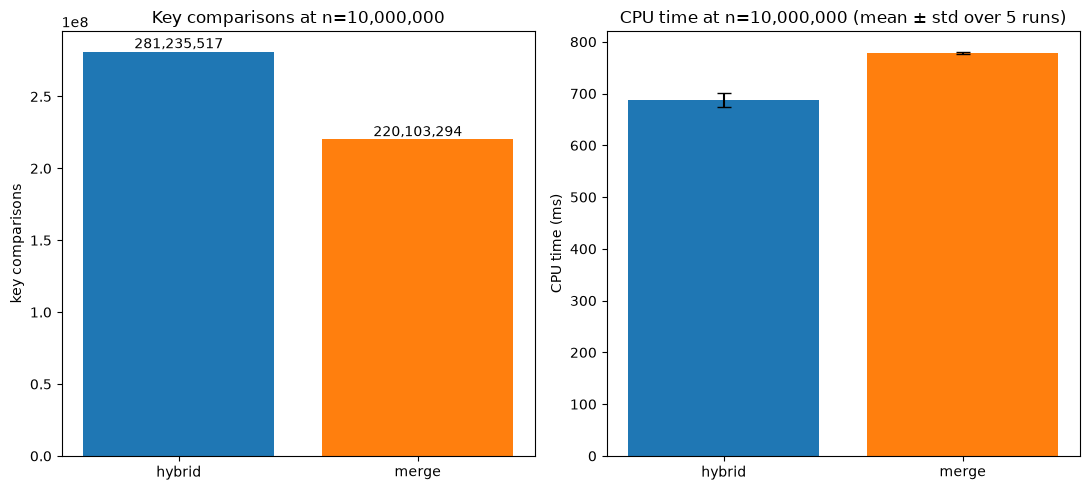

Hybrid (S=52) vs. plain Merge Sort at n=10,000,000:
  comparisons: 0.783x (hybrid/merge ratio: 1.278)
  CPU time:    1.133x speedup


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar(df_d["algo"], df_d["comparisons"], color=["tab:blue", "tab:orange"])
axes[0].set_ylabel("key comparisons")
axes[0].set_title(f"Key comparisons at n={N_LARGE:,}")
for i, v in enumerate(df_d["comparisons"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].bar(df_d["algo"], df_d["time_ms_mean"], yerr=df_d["time_ms_std"],
            color=["tab:blue", "tab:orange"], capsize=5)
axes[1].set_ylabel("CPU time (ms)")
axes[1].set_title(f"CPU time at n={N_LARGE:,} (mean ± std over {REPS} runs)")

plt.tight_layout()
plt.show()

speedup_comparisons = result_merge["comparisons"] / result_hybrid["comparisons"]
speedup_time = result_merge["time_ms_mean"] / result_hybrid["time_ms_mean"]
print(f"Hybrid (S={OPTIMAL_S}) vs. plain Merge Sort at n={N_LARGE:,}:")
print(f"  comparisons: {speedup_comparisons:.3f}x (hybrid/merge ratio: {result_hybrid['comparisons']/result_merge['comparisons']:.3f})")
print(f"  CPU time:    {speedup_time:.3f}x speedup")